In [1]:
print("MOVIE RATING PREDICTION")

MOVIE RATING PREDICTION


In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv(
    "IMDb Movies India.csv",
    encoding="latin1"
)
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
print(df.shape)
df.info()
df.isnull().sum()

(15509, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


In [7]:
df = df[
    [
        "Genre",
        "Director",
        "Actor 1",
        "Actor 2",
        "Actor 3",
        "Year",
        "Duration",
        "Votes",
        "Rating"
    ]
]

In [8]:
df = df.dropna()

In [13]:
#Year already numeric
df["Year"] = df["Year"].astype(int)
df["Year"].head()

,Year
1,2019
3,2019
5,1997
6,2005
8,2012


In [14]:
#convert to numeric
df["Duration"] = df["Duration"].str.replace(
    " min",
    "",
    regex=False
)
df["Duration"] = df["Duration"].astype(int)
df["Duration"].head()

,Duration
1,109
3,110
5,147
6,142
8,82


In [15]:
#convert to numeric
df["Votes"] = df["Votes"].str.replace(
    ",",
    "",
    regex=False
)
df["Votes"] = df["Votes"].astype(int)
df["Votes"].head()

,Votes
1,8
3,35
5,827
6,1086
8,326


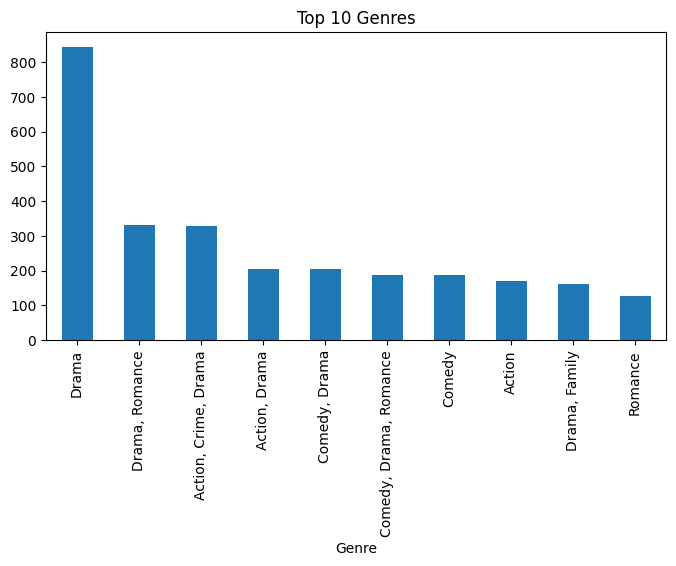

In [17]:
plt.figure(figsize=(8,4))
df["Genre"].value_counts().head(10).plot(
    kind="bar"
)
plt.title("Top 10 Genres")
plt.show()

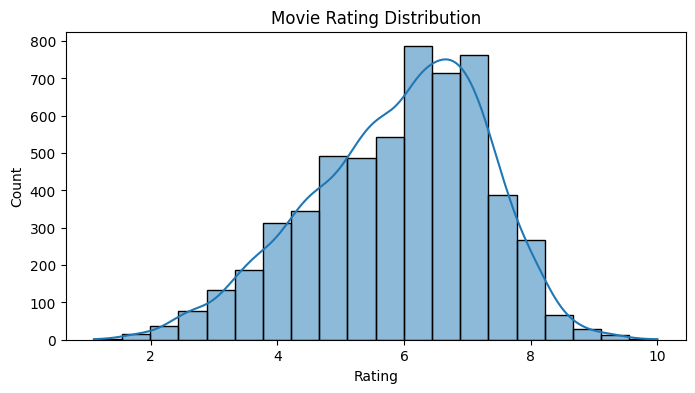

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)
plt.title("Movie Rating Distribution")
plt.show()

In [21]:
encoder = LabelEncoder()
df["Genre"] = encoder.fit_transform(
    df["Genre"]
)
df["Director"] = encoder.fit_transform(
    df["Director"]
)
df["Actor 1"] = encoder.fit_transform(
    df["Actor 1"]
)
df["Actor 2"] = encoder.fit_transform(
    df["Actor 2"]
)
df["Actor 3"] = encoder.fit_transform(
    df["Actor 3"]
)

In [22]:
X = df.drop("Rating", axis=1)
y = df["Rating"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LinearRegression()
model.fit(
    X_train,
    y_train
)
print("Model Trained Successfully")

Model Trained Successfully


In [25]:
predictions = model.predict(X_test)

In [26]:
mae = mean_absolute_error(
    y_test,
    predictions
)
r2 = r2_score(
    y_test,
    predictions
)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.0495625054893818
R2 Score: 0.08929055052181267


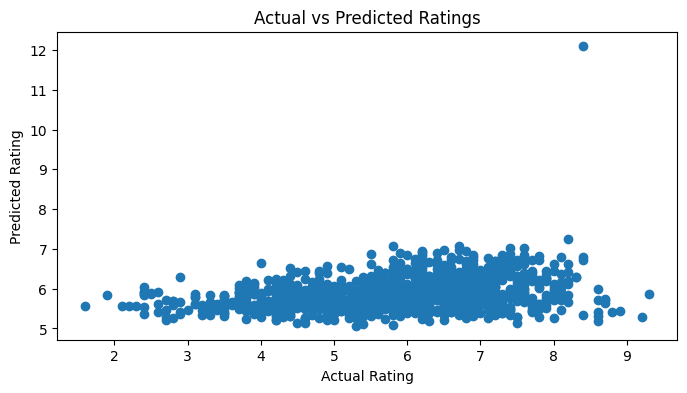

In [28]:
plt.figure(figsize=(8,4))
plt.scatter(
    y_test,
    predictions
)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(
    "Actual vs Predicted Ratings"
)
plt.show()

In [32]:
print("""The model successfully learned
patterns from historical movie data
and estimated movie ratings.""")

The model successfully learned
patterns from historical movie data
and estimated movie ratings.
